In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

df = pd.read_csv("C:/Data_Analyst_Journey/Luke Barousse/job_postings_flat.csv")

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [2]:
country = 'United States'
titles = df['job_title_short'].value_counts().reset_index()['job_title_short'].tolist()[:3]

df_selected = df[(df['job_country'] == country) & (df['job_title_short'].isin(titles))].copy()
df_exploded = df_selected.explode('job_skills')

df_jobs_total = df_selected['job_title_short'].value_counts().reset_index(name='jobs_total')
df_skills_count = df_exploded.groupby(['job_title_short', 'job_skills']).size().sort_values(ascending=False).reset_index(name='skill_count')

In [3]:
df_merged = pd.merge(df_skills_count, df_jobs_total, on='job_title_short', how='left')
df_merged['skill_percentage'] = 100 * df_merged['skill_count'] / df_merged['jobs_total']

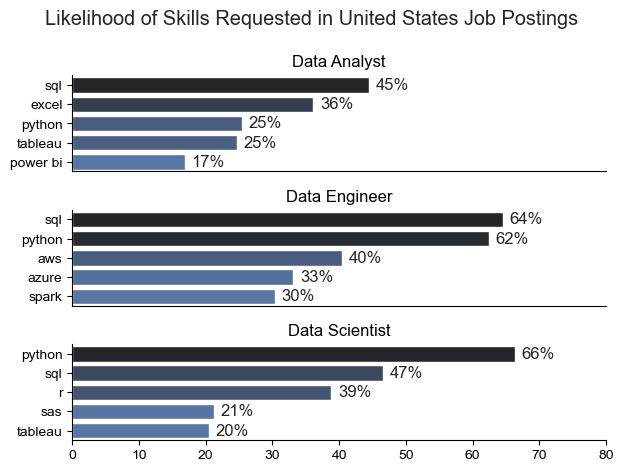

In [4]:
fig, ax = plt.subplots(len(titles), 1)
sns.set_theme(style='ticks')

for i, title in enumerate(titles):
    data_plot = df_merged[df_merged['job_title_short']==title].head(5)

    sns.barplot(data_plot, x='skill_percentage', y='job_skills', ax=ax[i], hue='skill_percentage', palette='dark:b_r')
    sns.despine()

    ax[i].set_title(title)
    ax[i].set_xlim(0, 80)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().remove()
    
    for n, v in enumerate(data_plot['skill_percentage']):
        ax[i].text(v+1, n, f'{v:.0f}%', va='center')

    if i != len(titles) - 1:
        ax[i].set_xticks([])

fig.suptitle(f'Likelihood of Skills Requested in {country} Job Postings')
fig.tight_layout()